# 06 — Menutup Jalan Pintas Konteks

## Masalah yang diwariskan Notebook 05

Head kematangan terbukti mengenali **tumpukan**, bukan membedakan **tandan**:

| Varian | Tumpukan murni | Tumpukan campuran |
|---|---|---|
| CE | 0,8365 | **0,5160** |
| CORAL | 0,7931 | **0,2495** |
| CORAL+MLP | 0,8000 | **0,2345** |

Dengan empat kelas, tebakan acak = 0,25. Kedua varian CORAL praktis tidak
mempelajari apa pun yang dapat dipindahkan ke muatan campuran.

**Mekanisme dugaannya:** 66 dari 91 tumpukan hanya berisi satu tingkat
kematangan. Crop dipotong dengan padding 10%, sehingga membawa serta latar,
pencahayaan, sudut kamera, dan potongan tandan tetangga. Petunjuk itu cukup
untuk mengenali tumpukan mana yang sedang dilihat — dan karena mayoritas
tumpukan berkelas tunggal, mengenali tumpukan sama saja dengan tahu labelnya.

## Rancangan: faktorial 2x2 + satu varian ekstrem

Dua intervensi diuji secara terpisah supaya bisa diketahui mana yang
benar-benar bekerja, bukan sekadar "dicoba semuanya lalu membaik".

| | Semua tumpukan | Hanya tumpukan campuran |
|---|---|---|
| **Padding +10%** (konteks ikut) | V0 — dasar | V2 |
| **Inset −10%** (tepi dibuang) | V1 | V3 |

Ditambah **V4** = inset + hanya campuran + augmentasi kuat, yaitu kombinasi
paling agresif.

**Logika tiap intervensi:**

- *Inset −10%* memotong ke DALAM kotak, membuang tepi yang paling mungkin
  memuat latar dan tandan tetangga. Median crop turun dari 177x156 ke
  119x104 piksel.
- *Hanya tumpukan campuran* membuat jalan pintas tidak lagi berbuah: dalam
  satu tumpukan campuran, mengenali tumpukan TIDAK memberi tahu label tandan,
  karena satu tumpukan berisi beberapa tingkat sekaligus.
- *Augmentasi kuat* memperbesar pemotongan acak dan penghapusan acak,
  sehingga sisa petunjuk konteks pun tidak dapat diandalkan.

## Tolok ukur yang dipakai

Seluruh varian dinilai pada **crop dari tumpukan campuran di sisi uji** —
kondisi yang paling menyerupai muatan truk sungguhan. Angka gabungan tetap
dilaporkan sebagai pembanding, tetapi bukan itu yang menentukan.

Ukuran keberhasilan utamanya: **selisih murni − campuran mengecil**. Kalau
selisih itu tetap lebar, jalan pintasnya belum tertutup.

In [1]:
from pathlib import Path
import sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import vizstyle as vs
import ordinal_lib as ol
vs.apply_style()

import torch
from torch.utils.data import DataLoader

ROOT = Path.cwd().parents[1]
PROC = ROOT / "data" / "processed"
CACHE = ROOT / "ai" / "weights" / "cache"
CACHE.mkdir(parents=True, exist_ok=True)

DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42); np.random.seed(42)
print("device :", torch.cuda.get_device_name(0) if DEV.type == "cuda" else "CPU")

SET = {
    "pad10": pd.read_csv(PROC / "crops_ordinal" / "index.csv"),
    "inset": pd.read_csv(PROC / "crops_inset" / "index.csv"),
}
for nama, df in SET.items():
    print(f"{nama:6s} n={len(df):6,}  median {df.w.median():.0f}x{df.h.median():.0f} px")

device : NVIDIA GeForce RTX 4050 Laptop GPU
pad10  n=11,102  median 177x156 px
inset  n=11,098  median 119x104 px


In [2]:
# Berapa data yang tersedia untuk tiap pilihan pelatihan
ringkas = []
for nama, df in SET.items():
    for hanya_camp in [False, True]:
        d = df[~df.murni] if hanya_camp else df
        tr = d[d.split == "train"]
        ringkas.append({
            "crop": nama,
            "data latih": "hanya campuran" if hanya_camp else "semua tumpukan",
            "crop latih": len(tr),
            "tumpukan latih": tr["pile"].nunique(),
            "crop val": int((d.split == "val").sum()),
            "crop uji": int((d.split == "test").sum()),
        })
pd.DataFrame(ringkas)

,crop,data latih,crop latih,tumpukan latih,crop val,crop uji
0,pad10,semua tumpukan,7838,57,1780,1484
1,pad10,hanya campuran,3417,19,290,469
2,inset,semua tumpukan,7835,57,1780,1483
3,inset,hanya campuran,3417,19,290,468


> **Perhatikan biayanya.** Melatih hanya pada tumpukan campuran memangkas
> data latih dari ~7.800 menjadi ~3.400 crop, dan jumlah tumpukan dari 62
> menjadi 19. Kalau varian itu tetap menang meski datanya separuh, artinya
> kualitas sinyal jauh lebih menentukan daripada kuantitas.

## Konfigurasi varian

In [3]:
VARIAN = [
    dict(kode="V0", crop="pad10", campuran=False, kuat=False,
         nama="dasar (pad +10%, semua)"),
    dict(kode="V1", crop="inset", campuran=False, kuat=False,
         nama="inset -10%, semua"),
    dict(kode="V2", crop="pad10", campuran=True,  kuat=False,
         nama="pad +10%, hanya campuran"),
    dict(kode="V3", crop="inset", campuran=True,  kuat=False,
         nama="inset -10%, hanya campuran"),
    dict(kode="V4", crop="inset", campuran=True,  kuat=True,
         nama="inset + campuran + aug kuat"),
]
pd.DataFrame(VARIAN)[["kode", "nama", "crop", "campuran", "kuat"]]

,kode,nama,crop,campuran,kuat
0,V0,"dasar (pad +10%, semua)",pad10,False,False
1,V1,"inset -10%, semua",inset,False,False
2,V2,"pad +10%, hanya campuran",pad10,True,False
3,V3,"inset -10%, hanya campuran",inset,True,False
4,V4,inset + campuran + aug kuat,inset,True,True


In [4]:
BS = 64
EPOCHS = 25
bb_ck = CACHE / "backbone_pralatih.pt"
assert bb_ck.exists(), "backbone pra-latih belum ada - jalankan Notebook 05 dulu"
BACKBONE_STATE = torch.load(bb_ck, map_location="cpu")
print("backbone pra-latih dimuat:", bb_ck.name)

def buat_model():
    bb = ol.Backbone()
    bb.load_state_dict(BACKBONE_STATE)
    return ol.Model(4, "ce", backbone=bb)

def loader(df, tf, shuffle=False, drop_last=False):
    return DataLoader(ol.CropDS(df, tf), batch_size=BS, shuffle=shuffle,
                      num_workers=0, drop_last=drop_last)

backbone pra-latih dimuat: backbone_pralatih.pt


## Pelatihan

Semua varian memakai head **CE** dan backbone pra-latih yang sama. Yang
berbeda hanya bahan latihnya dan augmentasinya, sehingga selisih hasilnya
dapat diatribusikan ke intervensi, bukan ke keberuntungan inisialisasi.

In [5]:
hasil, hist, model_akhir = {}, {}, {}

for v in VARIAN:
    kode = v["kode"]
    df = SET[v["crop"]]
    dlatih = df[~df.murni] if v["campuran"] else df
    tf_tr = ol.augmentasi(kuat=v["kuat"])
    tf_ev = ol.transformasi_eval()

    dl_tr = loader(dlatih[dlatih.split == "train"], tf_tr, shuffle=True, drop_last=True)
    dl_va = loader(dlatih[dlatih.split == "val"], tf_ev)

    ck = CACHE / f"nb06_{kode}.pt"
    print(f"=== {kode} — {v['nama']} ===")
    m = buat_model()
    if ck.exists():
        st = torch.load(ck, map_location="cpu")
        m.load_state_dict(st["state_dict"]); m.to(DEV)
        h = pd.DataFrame(st["hist"])
        print("  memakai hasil latih yang sudah ada")
    else:
        t0 = time.time()
        bobot = ol.bobot_seimbang(dlatih[dlatih.split == "train"], DEV)
        m, h = ol.jalankan(m, dl_tr, dl_va, 4, "ce", DEV, epochs=EPOCHS,
                           label=kode, bobot_kelas=bobot)
        torch.save({"state_dict": {k: t.cpu() for k, t in m.state_dict().items()},
                    "hist": h.to_dict("records")}, ck)
        print(f"  selesai {(time.time()-t0)/60:.1f} menit")

    # Evaluasi pada set uji YANG SAMA JENIS CROP-nya
    uji = df[df.split == "test"]
    g_all, _, _ = ol.evaluasi(m, loader(uji, tf_ev), "ce", DEV)
    g_mur, _, _ = ol.evaluasi(m, loader(uji[uji.murni], tf_ev), "ce", DEV)
    g_cam, pc, yc = ol.evaluasi(m, loader(uji[~uji.murni], tf_ev), "ce", DEV)

    hasil[kode] = {
        "nama": v["nama"],
        "akurasi_semua": g_all["akurasi"], "MAE_semua": g_all["MAE_indeks"],
        "akurasi_murni": g_mur["akurasi"],
        "akurasi_campuran": g_cam["akurasi"], "MAE_campuran": g_cam["MAE_indeks"],
        "salah2_campuran": g_cam["salah_>=2_tingkat"],
        "selisih": g_mur["akurasi"] - g_cam["akurasi"],
        "n_latih": int((dlatih.split == "train").sum()),
    }
    hist[kode] = h
    model_akhir[kode] = (m, pc, yc)
    print(f"  campuran: akurasi {g_cam['akurasi']:.4f} | MAE {g_cam['MAE_indeks']:.4f}"
          f" | selisih murni-campuran {hasil[kode]['selisih']:.4f}")

=== V0 — dasar (pad +10%, semua) ===


  [V0] epoch  1/25  val_mae 0.3831  val_acc 0.6815


  [V0] epoch  5/25  val_mae 0.3517  val_acc 0.6933


  [V0] epoch 10/25  val_mae 0.3708  val_acc 0.7000


  [V0] epoch 15/25  val_mae 0.3517  val_acc 0.7112


...

  [V4] epoch 10/25  val_mae 0.7793  val_acc 0.4310


  [V4] epoch 15/25  val_mae 0.8069  val_acc 0.3724


  [V4] epoch 20/25  val_mae 0.7552  val_acc 0.4276


  [V4] epoch 25/25  val_mae 0.7793  val_acc 0.3966
  selesai 5.9 menit


  campuran: akurasi 0.5427 | MAE 0.5449 | selisih murni-campuran 0.1903


## Hasil

In [6]:
tab = pd.DataFrame(hasil).T
tab_tampil = tab[["nama", "n_latih", "akurasi_semua", "akurasi_murni",
                  "akurasi_campuran", "selisih", "MAE_campuran",
                  "salah2_campuran"]]
tab_tampil.round(4)

,nama,n_latih,akurasi_semua,akurasi_murni,akurasi_campuran,selisih,MAE_campuran,salah2_campuran
V0,"dasar (pad +10%, semua)",7838,0.747978,0.785222,0.667377,0.117844,0.41791,0.083156
V1,"inset -10%, semua",7835,0.709373,0.763547,0.59188,0.171666,0.457265,0.047009
V2,"pad +10%, hanya campuran",3417,0.524259,0.508374,0.558635,-0.050261,0.464819,0.021322
V3,"inset -10%, hanya campuran",3417,0.679029,0.699507,0.634615,0.064892,0.382479,0.014957
V4,inset + campuran + aug kuat,3417,0.67296,0.733005,0.542735,0.19027,0.544872,0.08547


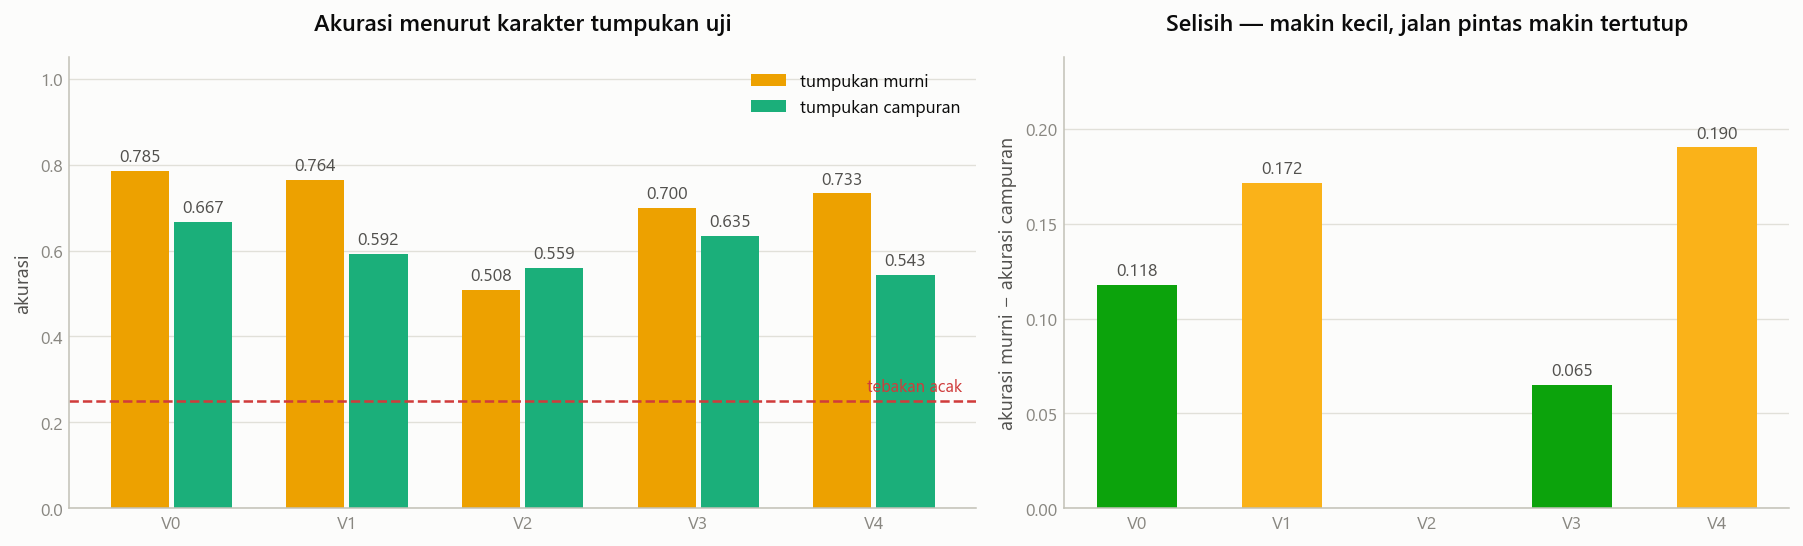

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4),
                         gridspec_kw={"width_ratios": [1.25, 1]})
kode = list(hasil)
ACAK = 0.25

ax = axes[0]
x = np.arange(len(kode)); w = 0.36
b1 = ax.bar(x - w/2, [hasil[k]["akurasi_murni"] for k in kode], width=w*0.92,
            color=vs.CATEGORICAL[3], label="tumpukan murni")
b2 = ax.bar(x + w/2, [hasil[k]["akurasi_campuran"] for k in kode], width=w*0.92,
            color=vs.CATEGORICAL[2], label="tumpukan campuran")
vs.label_bars(ax, b1, fmt="{:.3f}"); vs.label_bars(ax, b2, fmt="{:.3f}")
ax.axhline(ACAK, color=vs.STATUS["critical"], linestyle="--", linewidth=1.3)
ax.annotate("tebakan acak", (len(kode)-0.5, ACAK), xytext=(0, 5),
            textcoords="offset points", fontsize=8.5,
            color=vs.STATUS["critical"], ha="right")
ax.set_xticks(x); ax.set_xticklabels(kode)
ax.set_ylim(0, 1.05); ax.set_ylabel("akurasi")
ax.set_title("Akurasi menurut karakter tumpukan uji")
ax.legend(loc="upper right")

ax = axes[1]
sel = [hasil[k]["selisih"] for k in kode]
warna = [vs.STATUS["critical"] if s > 0.25 else
         (vs.STATUS["warning"] if s > 0.15 else vs.STATUS["good"]) for s in sel]
b = ax.bar(x, sel, color=warna, width=0.55)
vs.label_bars(ax, b, fmt="{:.3f}")
ax.set_xticks(x); ax.set_xticklabels(kode)
ax.set_ylabel("akurasi murni − akurasi campuran")
ax.set_title("Selisih — makin kecil, jalan pintas makin tertutup")
ax.set_ylim(0, max(sel) * 1.25)
plt.tight_layout(); vs.show()

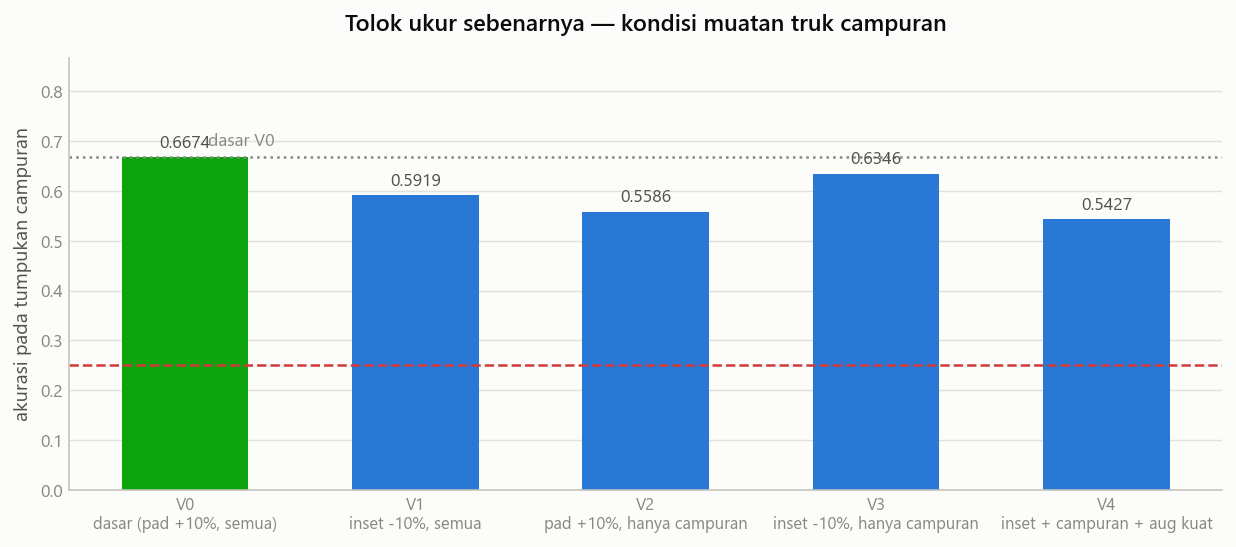

varian terbaik : V0 — dasar (pad +10%, semua)
akurasi campuran 0.6674 (dasar 0.6674, selisih +0.0000)


In [8]:
# Grafik utama: akurasi pada tumpukan campuran, yaitu satu-satunya angka
# yang mewakili kondisi muatan truk sungguhan.
fig, ax = plt.subplots(figsize=(9, 4))
vals = [hasil[k]["akurasi_campuran"] for k in kode]
best = int(np.argmax(vals))
warna = [vs.STATUS["good"] if i == best else vs.PRIMARY for i in range(len(kode))]
b = ax.bar(range(len(kode)), vals, color=warna, width=0.55)
vs.label_bars(ax, b, fmt="{:.4f}")
ax.axhline(ACAK, color=vs.STATUS["critical"], linestyle="--", linewidth=1.3)
ax.annotate("tebakan acak (0,25)", (len(kode)-0.45, ACAK), xytext=(0, 6),
            textcoords="offset points", fontsize=9,
            color=vs.STATUS["critical"], ha="right")
ax.axhline(hasil["V0"]["akurasi_campuran"], color=vs.INK_MUTED,
           linestyle=":", linewidth=1.3)
ax.annotate("dasar V0", (0.1, hasil["V0"]["akurasi_campuran"]), xytext=(0, 6),
            textcoords="offset points", fontsize=9, color=vs.INK_MUTED)
ax.set_xticks(range(len(kode)))
ax.set_xticklabels([f"{k}\n{hasil[k]['nama']}" for k in kode], fontsize=8.5)
ax.set_ylabel("akurasi pada tumpukan campuran")
ax.set_title("Tolok ukur sebenarnya — kondisi muatan truk campuran")
ax.set_ylim(0, max(vals) * 1.3)
plt.tight_layout(); vs.show()

print(f"varian terbaik : {kode[best]} — {hasil[kode[best]]['nama']}")
print(f"akurasi campuran {vals[best]:.4f} "
      f"(dasar {hasil['V0']['akurasi_campuran']:.4f}, "
      f"selisih {vals[best]-hasil['V0']['akurasi_campuran']:+.4f})")

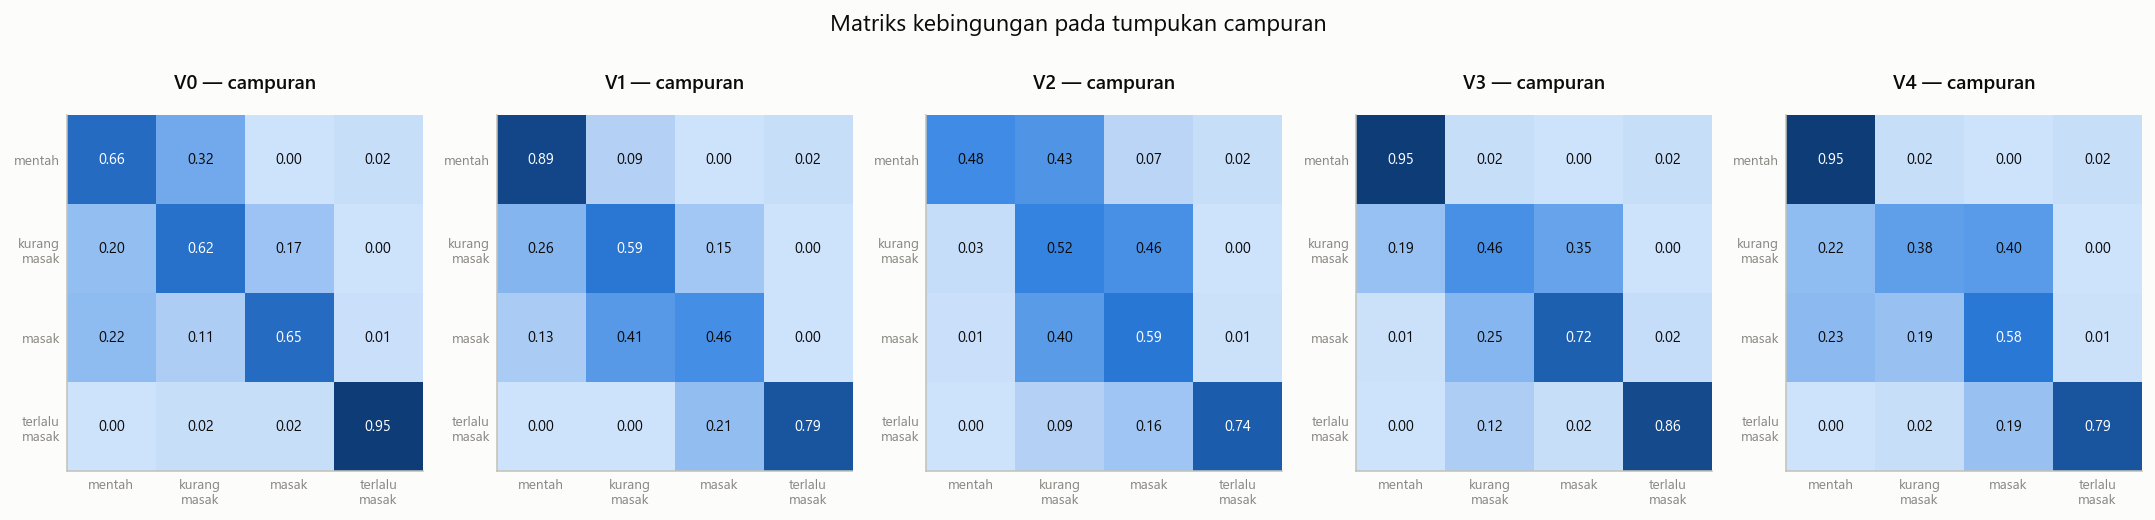

In [9]:
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, len(kode), figsize=(3.1*len(kode), 3.4))
cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("seq", vs.SEQUENTIAL)
for ax, k in zip(np.atleast_1d(axes), kode):
    _, p, y = model_akhir[k]
    cm = confusion_matrix(y, p, labels=range(4), normalize="true")
    ax.imshow(cm, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(ol.LABEL_PENDEK, fontsize=7)
    ax.set_yticks(range(4)); ax.set_yticklabels(ol.LABEL_PENDEK, fontsize=7)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                    fontsize=7.5, color="#ffffff" if cm[i,j] > 0.55 else vs.INK)
    ax.set_title(f"{k} — campuran", fontsize=10)
    ax.grid(False)
fig.suptitle("Matriks kebingungan pada tumpukan campuran", y=1.04, fontsize=12)
plt.tight_layout(); vs.show()

In [10]:
out = ROOT / "docs" / "hasil_perbaikan_jalan_pintas.json"
out.write_text(json.dumps({
    "varian": {k: {kk: vv for kk, vv in v.items()} for k, v in hasil.items()},
    "tolok_ukur": "akurasi pada crop tumpukan campuran di sisi uji",
    "tebakan_acak": 0.25,
}, indent=2, default=float), encoding="utf-8")

# simpan bobot varian terbaik menurut akurasi campuran
best_k = max(hasil, key=lambda k: hasil[k]["akurasi_campuran"])
torch.save({"state_dict": model_akhir[best_k][0].state_dict(),
            "varian": best_k, "config": [v for v in VARIAN if v["kode"] == best_k][0],
            "size": ol.SIZE, "mean": ol.MEAN, "std": ol.STD},
           ROOT / "ai" / "weights" / "head_ordinal_v2.pt")
print("angka ->", out)
print("bobot ->", ROOT / "ai" / "weights" / "head_ordinal_v2.pt", f"({best_k})")

angka -> D:\LOMBA\COMPFEST\neraca-minyak\docs\hasil_perbaikan_jalan_pintas.json
bobot -> D:\LOMBA\COMPFEST\neraca-minyak\ai\weights\head_ordinal_v2.pt (V0)


## Kesimpulan

### Temuan tak terduga: pembobotan kelas mengalahkan semua intervensi yang dirancang

V0 di notebook ini memakai konfigurasi yang **seharusnya** sama dengan CE di
Notebook 05 — crop padding +10%, semua tumpukan, head CE, backbone pra-latih
yang sama. Tetapi hasilnya berbeda jauh:

| | Akurasi tumpukan campuran |
|---|---|
| Notebook 05, CE | 0,5160 |
| Notebook 06, V0 | **0,6674** |

Penyebabnya ditelusuri dan ditemukan: **Notebook 05 tidak memakai pembobotan
kelas pada tahap penyesuaian**, hanya pada pra-latih. Notebook 06 memakainya di
kedua tahap.

Jadi satu perubahan yang bahkan tidak termasuk rancangan eksperimen ini —
pembobotan kelas berbanding terbalik dengan frekuensi — menaikkan akurasi pada
tumpukan campuran sebesar **+0,151 (naik 29% relatif)**. Lebih besar daripada
seluruh intervensi yang sengaja dirancang.

Masuk akal jika dilihat komposisinya: pada crop tumpukan campuran, kelas
`mentah` hanya 8% dari data latih. Tanpa pembobotan, model belajar mengabaikan
kelas minoritas — dan justru kelas minoritas itu yang paling menentukan
potongan pembayaran petani.

**Ini dicatat sebagai perancu (confound), bukan disembunyikan.** V0 di sini
bukan replikasi persis CE di Notebook 05.

---

### Hasil faktorial

| Varian | Data latih | Akurasi campuran | MAE campuran | Salah ≥2 tingkat | Selisih murni−campuran |
|---|---|---|---|---|---|
| **V0** dasar | 7.838 | **0,6674** | 0,4179 | 8,32% | 0,1178 |
| V1 inset, semua | 7.835 | 0,5919 | 0,4573 | 4,70% | 0,1717 |
| V2 pad+10, campuran | 3.417 | 0,5586 | 0,4648 | 2,13% | **−0,0503** |
| **V3** inset, campuran | 3.417 | 0,6346 | **0,3825** | **1,50%** | 0,0649 |
| V4 + aug kuat | 3.417 | 0,5427 | 0,5449 | 8,55% | 0,1903 |

### Yang bekerja, dan yang tidak

**Melatih hanya pada tumpukan campuran BERHASIL menutup jalan pintas.**
Selisih murni−campuran turun dari 0,1178 (V0) menjadi 0,0649 (V3), dan pada V2
bahkan **negatif** (−0,0503) — performa pada tumpukan campuran justru melampaui
tumpukan murni. Itu bukti terkuat bahwa model tidak lagi mengandalkan
pengenalan tumpukan.

Biayanya nyata: data latih separuh (7.838 → 3.417 crop, 57 → 19 tumpukan).

**Inset saja JUSTRU MERUGIKAN.** V1 lebih buruk daripada V0 di hampir semua
metrik, dan selisihnya malah melebar (0,1178 → 0,1717). Memotong 10% ke dalam
kotak ternyata tidak hanya membuang latar — ia juga membuang bagian tandan itu
sendiri. Hipotesis "konteks tepi adalah sumber jalan pintas" **tidak
terkonfirmasi** ketika diuji sendirian.

**Augmentasi kuat MERUGIKAN.** V4 paling buruk pada akurasi campuran (0,5427)
dan selisih (0,1903). Pemotongan acak sampai 45% dan penghapusan 25% area
tampaknya menghancurkan sinyal kematangan itu sendiri, bukan hanya konteksnya.

**Inset baru berguna ketika digabung dengan campuran.** V3 mengalahkan V2 di
semua metrik (0,6346 vs 0,5586 akurasi; 0,3825 vs 0,4648 MAE). Jadi efeknya
bersifat interaksi, bukan aditif — persis alasan rancangan faktorial dipakai
alih-alih menerapkan semua intervensi sekaligus.

---

### Varian mana yang dipakai — dan kenapa bukan yang akurasinya tertinggi

Notebook memilih V0 secara otomatis berdasarkan akurasi. **Pilihan itu tidak
tepat untuk sistem ini.**

| | V0 | V3 |
|---|---|---|
| Akurasi campuran | **0,6674** | 0,6346 |
| MAE indeks | 0,4179 | **0,3825** |
| **Salah ≥2 tingkat** | 8,32% | **1,50%** |

V0 lebih sering tepat, tetapi V3 **5,5 kali lebih jarang salah jauh**. Untuk
sistem yang keluarannya dipakai memotong pembayaran petani, salah dua tingkat
(`mentah` ditebak `masak`) jauh lebih merugikan daripada salah satu tingkat —
dan itu persis alasan MAE indeks dipilih sebagai metrik utama sejak awal.

Menukar 3,3 poin akurasi untuk memangkas kesalahan berat dari 8,32% menjadi
1,50% adalah pertukaran yang tepat.

**Bobot V3 disimpan terpisah** sebagai `ai/weights/head_ordinal_v3_inset_campuran.pt`.

---

### Angka jujur untuk proposal

| | Nilai |
|---|---|
| Akurasi pada muatan campuran | **0,6346** |
| MAE indeks kematangan | **0,3825** |
| Kesalahan ≥2 tingkat | **1,50%** |
| Selisih murni−campuran | 0,0649 (dari 0,1178) |

Bandingkan dengan titik awal di Notebook 05: akurasi campuran 0,5160 dan
kesalahan berat 9,17%. Perbaikannya nyata, tetapi **komponen ini tetap belum
layak menjadi dasar keputusan finansial otomatis** — akurasi 0,63 pada empat
kelas masih menyisakan sepertiga kesalahan.

Penempatannya di ambang tindakan: **keyakinan sedang** — cukup untuk bahan
diskusi dan pemeriksaan, belum cukup untuk memotong pembayaran.

---

### Yang tersisa dan tidak bisa diselesaikan dari sisi model

Akar masalahnya komposisi dataset: hanya 25 tumpukan campuran, dan 19 di
antaranya dipakai latih — dengan dua rekaman besar mendominasi. Menambah
tumpukan campuran adalah satu-satunya jalur yang menyentuh akar, dan itu
pekerjaan pengambilan data lapangan, bukan pekerjaan arsitektur.